In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

filename = '../data/sales_predictors.csv'
df = pd.read_csv(filename)

def find_nearest(array, value):
    idx = pd.Series(np.abs(array-value)).idxmin()
    return idx, array[idx]

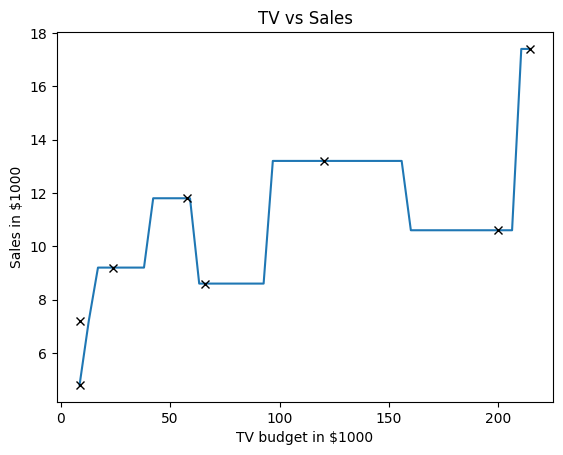

In [2]:
def part_1():
    # quick look on the data
    df.head()

    # Part 1 - kNN by hand k = 1

    # TV as predictor
    x_true = df.TV.iloc[5:13]

    # Sales as Response Variable
    y_true = df.Sales.iloc[5:13]

    # ordered index
    idx = np.argsort(x_true)
    # sort the data based on the idx, both x and y
    x_true = x_true.iloc[idx].values
    y_true = y_true.iloc[idx].values

    # synthetic values
    x = np.linspace(np.min(x_true), np.max(x_true))
    y = np.zeros(len(x))

    # Apply the KNN algorithm to predict the y-value for the given x value
    for i, xi in enumerate(x):
        y[i] = y_true[find_nearest(x_true, xi)[0]]

    plt.plot(x, y, '-')
    plt.plot(x_true, y_true, 'kx')

    plt.title('TV vs Sales')
    plt.xlabel('TV budget in $1000')
    plt.ylabel('Sales in $1000')

part_1()

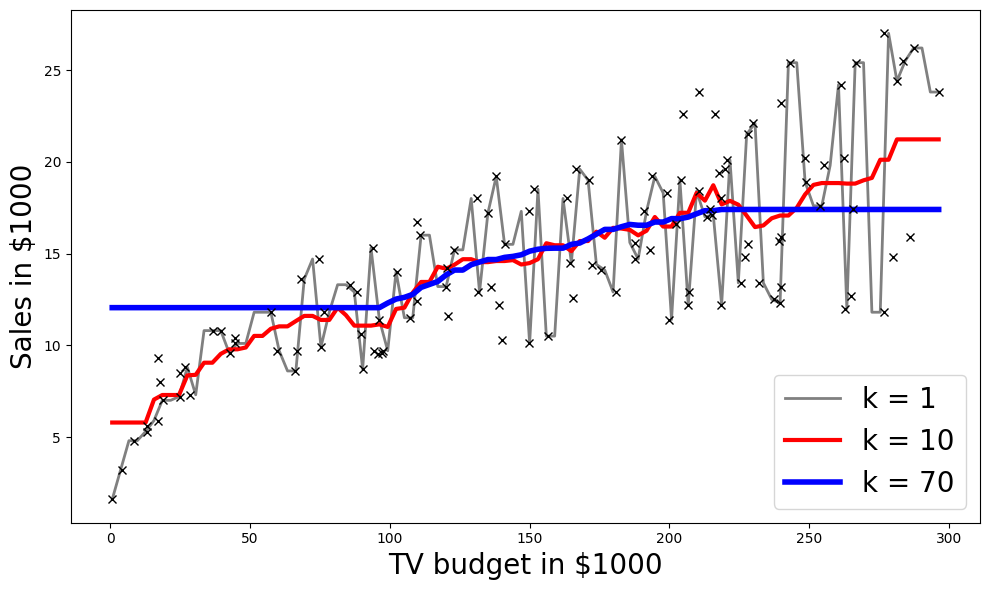

In [4]:
def part_2():
    x = df[["TV"]].values
    y = df[["Sales"]].values

    x_train, x_test, y_train, y_test = train_test_split(
            x,
            y,
            train_size=0.6,
            random_state=42
            )

    k_value_min = 1
    k_value_max = 70
    k_list = np.linspace(k_value_min, k_value_max, 70)

    fig, ax = plt.subplots(figsize=(10,6))
    j = 0
    for k_value in k_list:
        model = KNeighborsRegressor(n_neighbors=int(k_value))
        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)

        colors = ['grey', 'r', 'b']
        if k_value in [1, 10, 70]:
            xvals = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
            ypreds = model.predict(xvals)
            ax.plot(xvals, ypreds,'-',label = f'k = {int(k_value)}',linewidth=j+2,color = colors[j])
            j+=1

    ax.legend(loc='lower right',fontsize=20)
    ax.plot(x_train, y_train,'x',label='train',color='k')
    ax.set_xlabel('TV budget in $1000',fontsize=20)
    ax.set_ylabel('Sales in $1000',fontsize=20)
    plt.tight_layout()

part_2()